# Image Captioning (ResNet50 + Transformer)

In [ ]:
!nvidia-smi

Fri Sep 18 02:41:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/image_captioning'
os.makedirs(PROJECT_DIR, exist_ok=True)
print('Project directory:', PROJECT_DIR)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/image_captioning


In [ ]:
from google.colab import files
import zipfile

uploaded = files.upload()  # pick image_captioning.zip here

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as zf:
    zf.extractall('/content/')

# move the extracted folder's contents into our Drive project dir (only if not already there)
import shutil
extracted = '/content/image_captioning'
for item in os.listdir(extracted):
    s = os.path.join(extracted, item)
    d = os.path.join(PROJECT_DIR, item)
    if not os.path.exists(d):
        shutil.move(s, d)

os.chdir(PROJECT_DIR)
print('Now working in:', os.getcwd())
!ls

Saving image_captioning.zip to image_captioning.zip
Now working in: /content/drive/MyDrive/image_captioning
checkpoints		    evaluate.py		 model.py     requirements.txt
data			    generate_caption.py  outputs      train.py
{data,checkpoints,outputs}  gradcam.py		 __pycache__  vocab.py
dataset.py		    kaggle.json		 README.md


In [ ]:
!pip install -q nltk opencv-python-headless
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
from google.colab import files
import os

os.makedirs('/root/.kaggle', exist_ok=True)
uploaded = files.upload()  # pick kaggle.json here
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json
!pip install -q kaggle

!kaggle datasets download -d adityajn105/flickr8k -p /content/flickr8k_zip
!unzip -q /content/flickr8k_zip/flickr8k.zip -d /content/flickr8k_raw
!ls /content/flickr8k_raw

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:09<00:00, 114MB/s]

captions.txt  Images


In [ ]:
# Arrange into the layout our code expects: data/Images/ + data/captions.txt
import shutil, os

data_dir = os.path.join(PROJECT_DIR, 'data')
os.makedirs(data_dir, exist_ok=True)

src_images = '/content/flickr8k_raw/Images'
src_captions = '/content/flickr8k_raw/captions.txt'

dst_images = os.path.join(data_dir, 'Images')
if not os.path.exists(dst_images):
    shutil.move(src_images, dst_images)

dst_captions = os.path.join(data_dir, 'captions.txt')
if not os.path.exists(dst_captions):
    shutil.move(src_captions, dst_captions)

print('Images:', len(os.listdir(dst_images)))
!head -5 {dst_captions}

Images: 8091
image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .
1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .


**Option B — manual upload instead of Kaggle API:**
If you already have the dataset zip downloaded, skip the two cells above and instead run:
```python
from google.colab import files
uploaded = files.upload()  # pick your flickr8k zip
!unzip -q <your_zip_name>.zip -d /content/flickr8k_raw
```
then continue with the "Arrange into layout" cell above.

## Train


In [ ]:
os.chdir(PROJECT_DIR)
!python train.py --data_dir data --epochs 15 --batch_size 64 --num_workers 2

Using device: cuda
Building vocabulary...
Vocabulary size: 2995
Train samples: 36410 | Val samples: 4045
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100% 97.8M/97.8M [00:00<00:00, 153MB/s]
Trainable params: 35,900,851 / 44,444,147
Epoch 1/15 [train]: 100% 569/569 [08:04<00:00,  1.18it/s, loss=2.9]
Epoch 1: train_loss=3.4158 val_loss=2.7677 elapsed=8.7min
  -> Saved new best checkpoint (val_loss=2.7677) to checkpoints/best_model.pt
Epoch 2/15 [train]: 100% 569/569 [06:07<00:00,  1.55it/s, loss=2.46]
Epoch 2: train_loss=2.5451 val_loss=2.4817 elapsed=15.6min
  -> Saved new best checkpoint (val_loss=2.4817) to checkpoints/best_model.pt
Epoch 3/15 [train]: 100% 569/569 [06:22<00:00,  1.49it/s, loss=2.06]
Epoch 3: train_loss=2.2006 val_loss=2.3639 elapsed=22.6min
  -> Saved new best checkpoint (val_loss=2.3639) to checkpoints/best_model.pt
Epoch 4/15 [train]: 100% 569/569 [06:15<00:00,  1.52it/s, loss=2

## Evaluate BLEU-4

In [ ]:
!python evaluate.py --checkpoint checkpoints/best_model.pt --data_dir data --num_images 500

Evaluating: 100% 500/500 [00:42<00:00, 11.81it/s]

Evaluated on 500 images
BLEU-1: 0.8335
BLEU-4: 0.4990


## Generate a caption for one image

In [ ]:
import os
sample_image = os.path.join(PROJECT_DIR, 'data', 'Images', os.listdir(os.path.join(PROJECT_DIR, 'data', 'Images'))[0])
print('Using sample image:', sample_image)
!python generate_caption.py --checkpoint checkpoints/best_model.pt --image "{sample_image}"

Using sample image: /content/drive/MyDrive/image_captioning/data/Images/393958545_48c17c66d1.jpg

Image: /content/drive/MyDrive/image_captioning/data/Images/393958545_48c17c66d1.jpg
Generated caption: a black lab is running through a race


## Grad-CAM explainability

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
Generated caption: a black lab is running through a race
Saved Grad-CAM visualization to outputs/gradcam.png


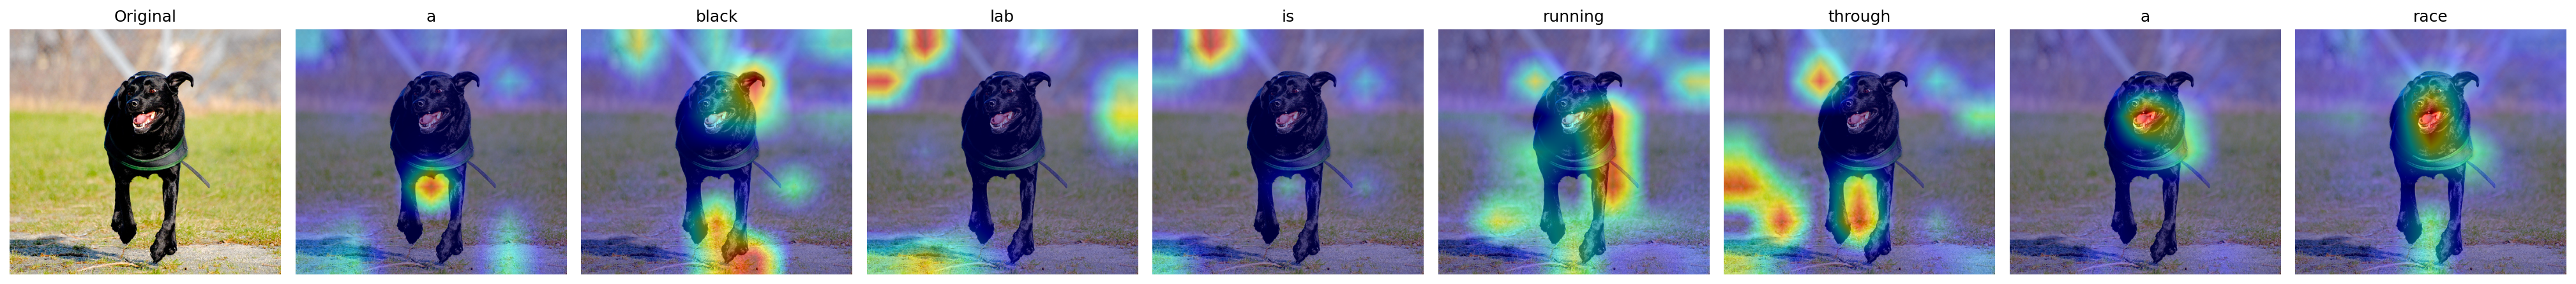

In [ ]:
!python gradcam.py --checkpoint checkpoints/best_model.pt --image "{sample_image}" --out outputs/gradcam.png

from IPython.display import Image as IPImage, display
display(IPImage(filename='outputs/gradcam.png'))